# Diabetes Risk Classification System

A machine learning pipeline for diabetes risk classification utilizing the Pima Indians Diabetes Database. This notebook compares an SVM with an MLP, integrates SHAP for feature explainability, and includes an ethical bias audit.

Count of non-biological zeros:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


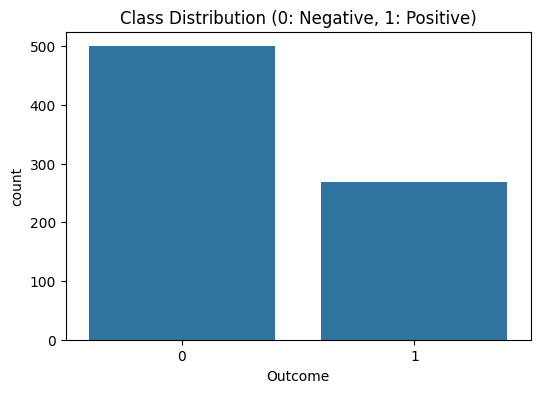

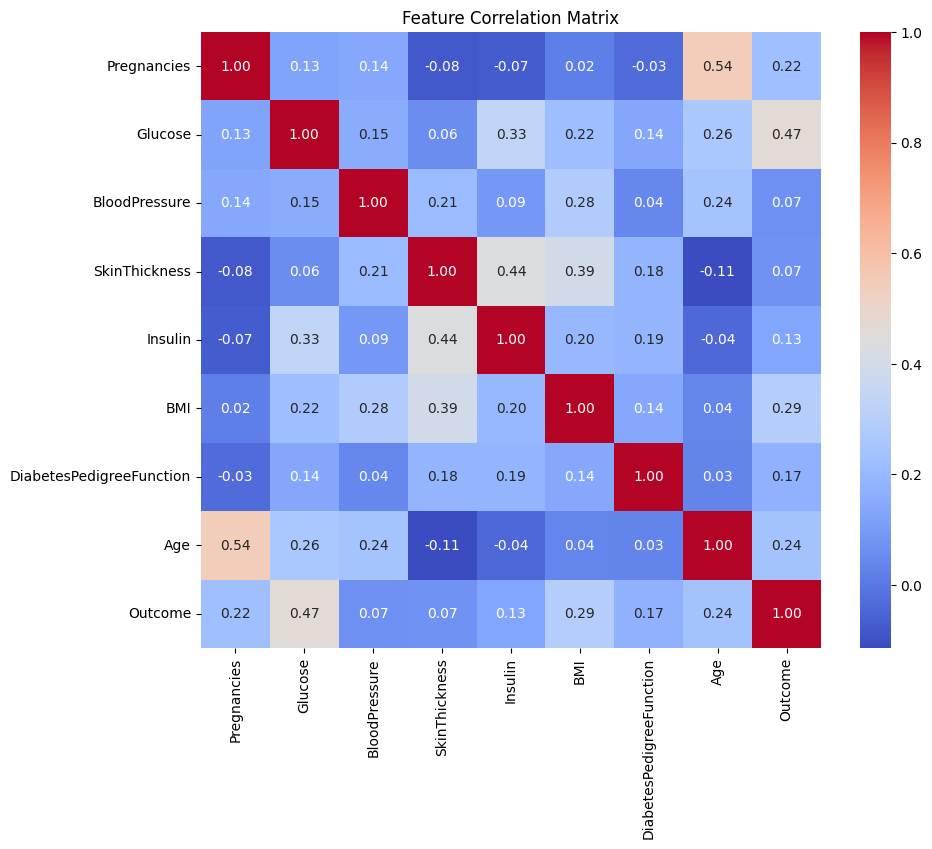

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('diabetes.csv')

# Audit for physiological anomalies (non-biological zeros)
anomalous_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of non-biological zeros:")
for feature in anomalous_features:
    zero_count = (df[feature] == 0).sum()
    print(f"{feature}: {zero_count}")

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Class Distribution (0: Negative, 1: Positive)')
plt.show()

# Visualize feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

## Phase 1: Statistical Exploration (Clinical EDA)

Loading clinical data and auditing for physiological anomalies (e.g., non-biological zeros). Visualizing feature distributions and correlations.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Replace non-biological zeros with NaN for proper imputation
df[anomalous_features] = df[anomalous_features].replace(0, np.nan)

# Impute missing values with the median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(df.drop('Outcome', axis=1)), columns=df.columns[:-1])
y = df['Outcome']

# Perform Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling with SHAP later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## Phase 2: Normalization and Feature Engineering

Preprocessing pipeline steps:
1. Impute missing values using the median.
2. Apply Z-score Standardization.
3. Perform a stratified 80/20 train-test split.

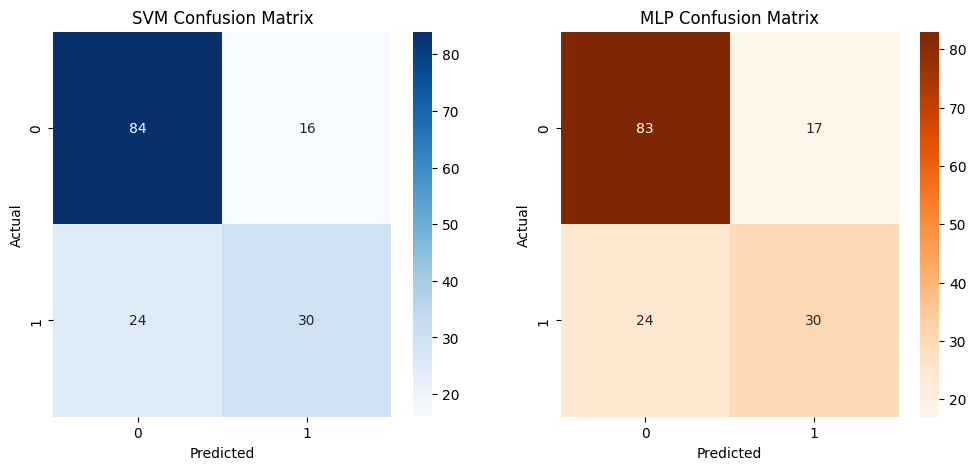

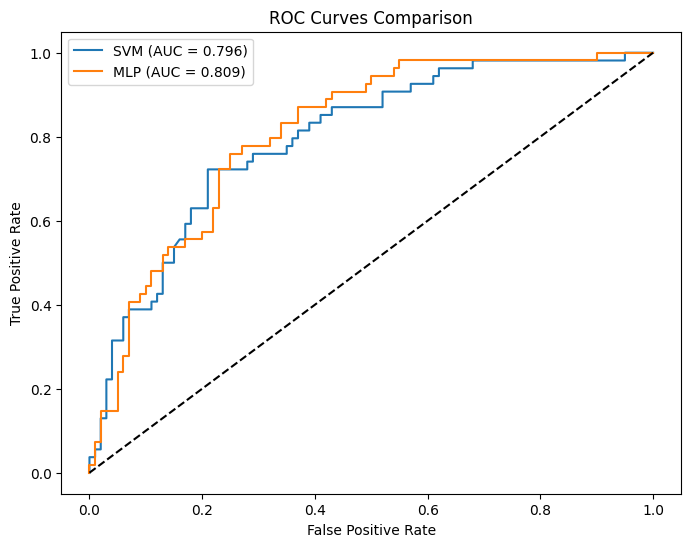

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- SVM Implementation ---
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

# --- Neural Network (MLP) Implementation ---
class ClinicalMLP(nn.Module):
    def __init__(self, input_dim):
        super(ClinicalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Prepare PyTorch Tensors
X_train_t = torch.FloatTensor(X_train_scaled.values)
y_train_t = torch.FloatTensor(y_train.values).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled.values)
y_test_t = torch.FloatTensor(y_test.values).unsqueeze(1)

# Training loop
mlp_model = ClinicalMLP(X_train_scaled.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.005)

epochs = 150
for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

mlp_model.eval()
with torch.no_grad():
    mlp_probs = mlp_model(X_test_t).squeeze().numpy()
    mlp_preds = (mlp_probs >= 0.5).astype(int)

# --- Evaluation & Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrices
sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, mlp_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('MLP Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.show()

# ROC Curves
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

## Phase 3: Modeling (SVM vs. Neural Network)

Comparison of two model architectures:
1. **SVM (RBF Kernel)**: Standard distance-based classification.
2. **MLP (PyTorch)**: A 3-layer neural network with Dropout.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

Global Feature Importance (Summary Plot)


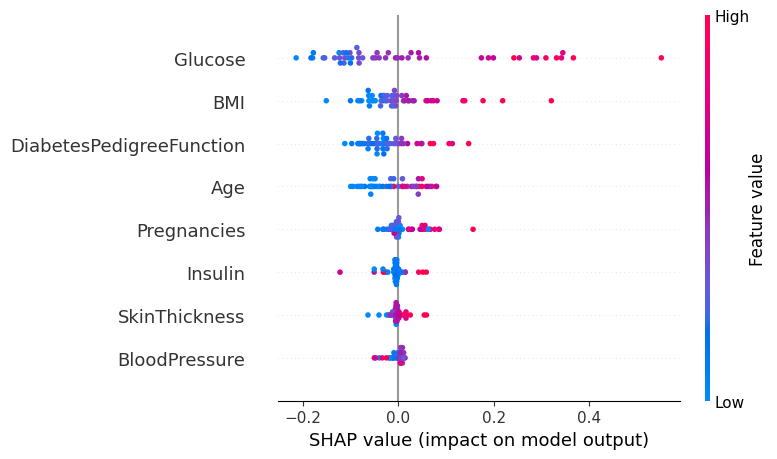

Single Patient Risk Explanation (Force Plot)


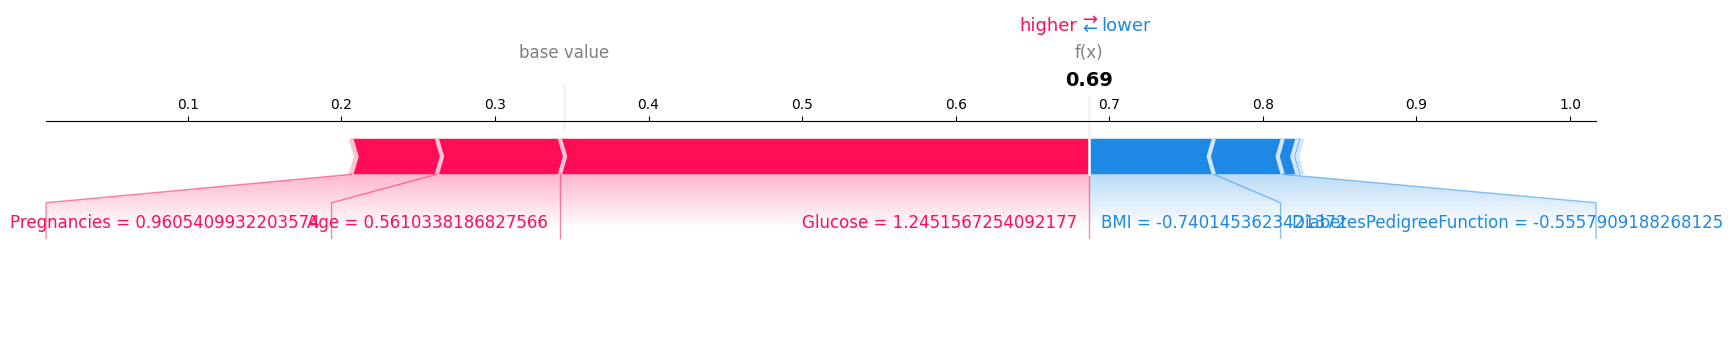

In [6]:
import shap

# Initialize JavaScript visualization for SHAP
shap.initjs()

# We will explain the SVM model using SHAP KernelExplainer
# We use a background dataset (kmeans summary) to speed up computation
background = shap.kmeans(X_train_scaled, 10)
# We explain the probabilities of the positive class (index 1) directly
explainer = shap.KernelExplainer(lambda x: svm_model.predict_proba(x)[:, 1], background)

# Calculate SHAP values for the test set
# (Selecting a subset for performance in this notebook)
X_test_subset = X_test_scaled.iloc[:50]
shap_values = explainer.shap_values(X_test_subset)

# Plot 1: Global Feature Importance (Summary Plot)
print("Global Feature Importance (Summary Plot)")
# Since we explained only the positive class, shap_values is a single matrix
shap.summary_plot(shap_values, X_test_subset, plot_type="dot")

# Plot 2: Local Patient Prediction (Force Plot)
print("Single Patient Risk Explanation (Force Plot)")
patient_index = 0
# Force plot for the first patient in the test subset
shap.force_plot(explainer.expected_value, shap_values[patient_index,:], X_test_subset.iloc[patient_index,:], matplotlib=True)

## Phase 4: Clinical Explainability with SHAP

Utilizing SHAP (SHapley Additive exPlanations) to quantify feature contributions, validate clinical intuition, and generate localized patient predictions.